In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [2]:
import pandas as pd
import numpy as np

In [3]:
import os
print(os.listdir(path))

['Titanic-Dataset.csv']


In [4]:
import os
df = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"))

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df[df.duplicated]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.shape

(891, 12)

In [11]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

/tmp/ipykernel_19159/2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [12]:
df.drop('Cabin',axis=1,inplace=True)

In [13]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

/tmp/ipykernel_19159/548196730.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)


In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [15]:
df["Sex"]=le.fit_transform(df['Sex'])
df["Embarked"]=le.fit_transform(df['Embarked'])

In [16]:
df.drop('Name',axis=1,inplace=True)

In [17]:
df.drop('Ticket',axis=1,inplace=True)

In [18]:
df.drop('PassengerId',axis=1,inplace=True)

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [21]:
y=df['Survived']
df.drop('Survived',axis=1,inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Sex         891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Embarked    891 non-null    int64  
 7   FamilySize  891 non-null    int64  
 8   IsAlone     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


In [23]:
x_train,x_test,y_train,y_test=train_test_split(df,y,test_size=0.2,random_state=42)

In [24]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
331,1,1,45.500000,0,0,28.5000,2,1,1
733,2,1,23.000000,0,0,13.0000,2,1,1
382,3,1,32.000000,0,0,7.9250,2,1,1
704,3,1,26.000000,1,0,7.8542,2,2,0
813,3,0,6.000000,4,2,31.2750,2,7,0
...,...,...,...,...,...,...,...,...,...
106,3,0,21.000000,0,0,7.6500,2,1,1
270,1,1,29.699118,0,0,31.0000,2,1,1
860,3,1,41.000000,2,0,14.1083,2,3,0
435,1,0,14.000000,1,2,120.0000,2,4,0


In [25]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
709,3,1,29.699118,1,1,15.2458,0,3,0
439,2,1,31.000000,0,0,10.5000,2,1,1
840,3,1,20.000000,0,0,7.9250,2,1,1
720,2,0,6.000000,0,1,33.0000,2,2,0
39,3,0,14.000000,1,0,11.2417,0,2,0
...,...,...,...,...,...,...,...,...,...
433,3,1,17.000000,0,0,7.1250,2,1,1
773,3,1,29.699118,0,0,7.2250,0,1,1
25,3,0,38.000000,1,5,31.3875,2,7,0
84,2,0,17.000000,0,0,10.5000,2,1,1


In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
model1=LogisticRegression()
model1.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
y_pred=model1.predict(x_test)

In [29]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [30]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [31]:
accuracy1=accuracy_score(y_test,y_pred)
accuracy1

0.8044692737430168

In [32]:
cm=confusion_matrix(y_test,y_pred)
x=classification_report(y_test,y_pred)
print(x)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



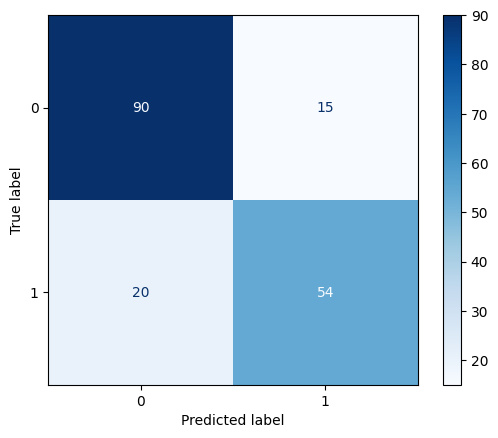

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot(cmap=plt.cm.Blues)
plt.show()

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
model2=DecisionTreeClassifier()
model2.fit(x_train,y_train)

DecisionTreeClassifier()

In [36]:
y_pred2=model2.predict(x_test)

In [37]:
accuracy2=accuracy_score(y_test,y_pred2)
accuracy2

0.7877094972067039

In [38]:
cm2=confusion_matrix(y_test,y_pred2)
x2=classification_report(y_test,y_pred2)
print(x2)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



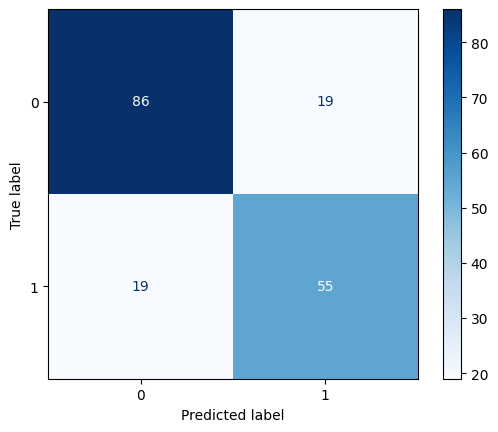

In [39]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm2)
cmd.plot(cmap=plt.cm.Blues)
plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
model3=RandomForestClassifier(n_estimators=100,max_depth=10)
model3.fit(x_train,y_train)

RandomForestClassifier(max_depth=10)

In [48]:
y_pred3=model3.predict(x_test)

In [49]:
accuracy3=accuracy_score(y_test,y_pred3)
accuracy3

0.8324022346368715

In [50]:
cm3=confusion_matrix(y_test,y_pred3)
x3=classification_report(y_test,y_pred3)
print(x3)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



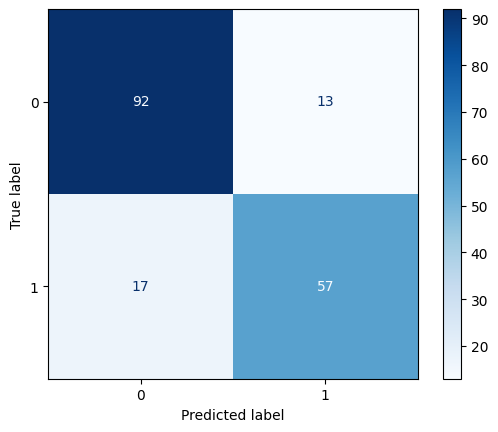

In [51]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm3)
cmd.plot(cmap=plt.cm.Blues)
plt.show()

In [46]:
## By evaluating all three models its clear that RandomForest is giving better accuracy and Decision Tree and Logistic Regression are comparatively less. And after evaluating confustion metrics TP and TN values are high in RandomForest.